# 1. Data Import & Engineering

**Dataset:** CIC-IDS2017 - Network traffic data collected over 5 working days (July 3–7, 2017).  
**Goal:** Load, clean, explore, and prepare the data for ML and Graph ML pipelines.

**Outputs:** Cleaned CSVs saved to `prepared_data/` for downstream notebooks.

## Configuration

All configurable settings for this notebook are defined below using Pydantic models.  
Edit these values before running to customize behavior.

In [1]:
from pydantic import BaseModel, Field
from typing import List, Optional


class DataPathsConfig(BaseModel):
    """Paths to raw data and output directory."""
    ml_folder: str = Field(default="MachineLearningCVE", description="Path to MachineLearningCVE CSVs")
    tl_folder: str = Field(default="TrafficLabelling", description="Path to TrafficLabelling CSVs")
    output_dir: str = Field(default="prepared_data", description="Directory to save prepared data")


class DataPrepConfig(BaseModel):
    """Data preparation settings."""
    remove_duplicates: bool = Field(default=True, description="Remove duplicate rows from datasets")
    drop_constant_columns: bool = Field(default=True, description="Drop columns with zero variance")
    drop_redundant_columns: bool = Field(default=True, description="Drop perfectly correlated columns (|r|=1.0)")
    save_prepared_csvs: bool = Field(default=True, description="Save cleaned dataframes to CSV")


class CorrelationFeatureSelectionConfig(BaseModel):
    """Feature selection based on correlation with target label."""
    enabled: bool = Field(default=True, description="Enable correlation-based feature selection")
    correlation_threshold: float = Field(default=0.3, description="Min |correlation| with target to keep a feature")
    method: str = Field(default="spearman", description="Correlation method: 'pearson' or 'spearman'")


class EDAConfig(BaseModel):
    """EDA visualization settings."""
    run_eda: bool = Field(default=True, description="Run EDA visualizations")
    key_features: List[str] = Field(
        default=[
            'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
            'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
            'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean',
            'Bwd Packet Length Mean', 'Flow IAT Mean', 'Destination Port',
            'Average Packet Size'
        ],
        description="Features to visualize in histograms"
    )

paths_cfg = DataPathsConfig()
prep_cfg = DataPrepConfig()
corr_cfg = CorrelationFeatureSelectionConfig()
eda_cfg = EDAConfig()

print("Configuration loaded:")
print(f"  Paths: ML={paths_cfg.ml_folder}, TL={paths_cfg.tl_folder}, Output={paths_cfg.output_dir}")
print(f"  Prep: duplicates={prep_cfg.remove_duplicates}, constants={prep_cfg.drop_constant_columns}, redundant={prep_cfg.drop_redundant_columns}")
print(f"  Correlation selection: enabled={corr_cfg.enabled}, threshold={corr_cfg.correlation_threshold}, method={corr_cfg.method}")
print(f"  EDA: enabled={eda_cfg.run_eda}")
print(f"  Save CSVs: {prep_cfg.save_prepared_csvs}")

Configuration loaded:
  Paths: ML=MachineLearningCVE, TL=TrafficLabelling, Output=prepared_data
  Prep: duplicates=True, constants=True, redundant=True
  Correlation selection: enabled=True, threshold=0.3, method=spearman
  EDA: enabled=True
  Save CSVs: True


## 1.1 Setup & Imports

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("All imports successful.")

All imports successful.


## 2.1 Load MachineLearningCVE

In [3]:
ml_files = sorted([f for f in os.listdir(paths_cfg.ml_folder) if f.endswith('.csv')])

print(f"Files in {paths_cfg.ml_folder}:")
ml_dfs = []
for f in ml_files:
    df = pd.read_csv(os.path.join(paths_cfg.ml_folder, f), encoding='utf-8-sig', low_memory=False)
    df.columns = df.columns.str.strip()
    df['source_file'] = f
    ml_dfs.append(df)
    print(f"    {f} - loaded")

ml_df = pd.concat(ml_dfs, ignore_index=True)

ml_df['Label'] = ml_df['Label'].str.replace(r'[^\x20-\x7E]+', '-', regex=True)

print(f"\nTotal rows: {ml_df.shape[0]:,} \nTotal columns: {ml_df.shape[1]}")

Files in MachineLearningCVE:
    Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv - loaded
    Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv - loaded
    Friday-WorkingHours-Morning.pcap_ISCX.csv - loaded
    Monday-WorkingHours.pcap_ISCX.csv - loaded
    Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv - loaded
    Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv - loaded
    Tuesday-WorkingHours.pcap_ISCX.csv - loaded
    Wednesday-workingHours.pcap_ISCX.csv - loaded

Total rows: 2,830,743 
Total columns: 80


In [4]:
print(f"\nSample rows:")
ml_df.head()


Sample rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.00,0.00,0,0,0.00,0.00,4000000.00,666666.67,3.00,0.00,3,3,3,3.00,0.00,3,3,0,0.00,0.00,0,0,0,0,0,0,40,0,666666.67,0.00,6,6,6.00,0.00,0.00,0,0,0,0,1,0,0,0,0,9.00,6.00,0.00,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.00,0.00,6,6,6.00,0.00,110091.74,18348.62,109.00,0.00,109,109,0,0.00,0.00,0,0,0,0.00,0.00,0,0,0,0,0,0,20,20,9174.31,9174.31,6,6,6.00,0.00,0.00,0,0,0,0,1,1,0,0,1,9.00,6.00,6.00,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.00,0.00,6,6,6.00,0.00,230769.23,38461.54,52.00,0.00,52,52,0,0.00,0.00,0,0,0,0.00,0.00,0,0,0,0,0,0,20,20,19230.77,19230.77,6,6,6.00,0.00,0.00,0,0,0,0,1,1,0,0,1,9.00,6.00,6.00,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.00,0.00,6,6,6.00,0.00,352941.18,58823.53,34.00,0.00,34,34,0,0.00,0.00,0,0,0,0.00,0.00,0,0,0,0,0,0,20,20,29411.76,29411.76,6,6,6.00,0.00,0.00,0,0,0,0,1,1,0,0,1,9.00,6.00,6.00,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.00,0.00,0,0,0.00,0.00,4000000.00,666666.67,3.00,0.00,3,3,3,3.00,0.00,3,3,0,0.00,0.00,0,0,0,0,0,0,40,0,666666.67,0.00,6,6,6.00,0.00,0.00,0,0,0,0,1,0,0,0,0,9.00,6.00,0.00,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.00,0.00,0,0,0.00,0.00,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [5]:
print("Class Distribution (MachineLearningCVE)\n")
label_counts = ml_df['Label'].value_counts()
print(label_counts.to_string())

print(f"\nTotal samples: {label_counts.sum():,}")
print(f"Unique labels: {ml_df['Label'].nunique()}")

print(f"\nPercentage distribution:")
print((label_counts / label_counts.sum() * 100).round(2).to_string())

Class Distribution (MachineLearningCVE)

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11

Total samples: 2,830,743
Unique labels: 15

Percentage distribution:
Label
BENIGN                       80.30
DoS Hulk                      8.16
PortScan                      5.61
DDoS                          4.52
DoS GoldenEye                 0.36
FTP-Patator                   0.28
SSH-Patator                   0.21
DoS slowloris                 0.20
DoS Slowhttptest           

## 2.2 Load TrafficLabelling

In [6]:
tl_files = sorted([f for f in os.listdir(paths_cfg.tl_folder) if f.endswith('.csv')])

print(f"Files in {paths_cfg.tl_folder}:")

tl_dfs = []
for f in tl_files:
    try:
        df = pd.read_csv(os.path.join(paths_cfg.tl_folder, f), encoding='utf-8-sig', low_memory=False)
    except UnicodeDecodeError:
        df = pd.read_csv(os.path.join(paths_cfg.tl_folder, f), encoding='cp1252', low_memory=False)

    df.columns = df.columns.str.strip()
    df['source_file'] = f
    tl_dfs.append(df)
    print(f"    {f} - loaded")

tl_df = pd.concat(tl_dfs, ignore_index=True)

tl_df['Label'] = tl_df['Label'].str.replace(r'[^\x20-\x7E]+', '-', regex=True)

print(f"\nTotal rows: {tl_df.shape[0]:,} \nTotal columns: {tl_df.shape[1]}")

Files in TrafficLabelling:
    Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv - loaded
    Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv - loaded
    Friday-WorkingHours-Morning.pcap_ISCX.csv - loaded
    Monday-WorkingHours.pcap_ISCX.csv - loaded
    Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv - loaded
    Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv - loaded
    Tuesday-WorkingHours.pcap_ISCX.csv - loaded
    Wednesday-workingHours.pcap_ISCX.csv - loaded

Total rows: 3,119,345 
Total columns: 86


In [7]:
ml_cols = set(ml_df.columns) - {'source_file'}
tl_cols = set(tl_df.columns) - {'source_file'}

extra_in_tl = tl_cols - ml_cols
extra_in_ml = ml_cols - tl_cols

if extra_in_tl:
    print("Columns in TrafficLabelling but not in MachineLearningCVE:")
    for c in sorted(extra_in_tl):
        print(f"  {c}")
else:
    print("\nNo columns in TrafficLabelling that are not in MachineLearningCVE.")

if extra_in_ml:
    print("\nColumns in MachineLearningCVE but not in TrafficLabelling:")
    for c in sorted(extra_in_ml):
        print(f"  {c}")
else:
    print("\nNo columns in MachineLearningCVE that are not in TrafficLabelling.")

print(f"\nTrafficLabelling sample (graph-relevant columns):")
graph_cols = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Label']
tl_df[graph_cols].head(10)

Columns in TrafficLabelling but not in MachineLearningCVE:
  Destination IP
  Flow ID
  Protocol
  Source IP
  Source Port
  Timestamp

No columns in MachineLearningCVE that are not in TrafficLabelling.

TrafficLabelling sample (graph-relevant columns):


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443.00,192.168.10.5,54865.00,6.00,7/7/2017 3:30,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80.00,192.168.10.5,55054.00,6.00,7/7/2017 3:30,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80.00,192.168.10.5,55055.00,6.00,7/7/2017 3:30,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443.00,192.168.10.16,46236.00,6.00,7/7/2017 3:30,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443.00,192.168.10.5,54863.00,6.00,7/7/2017 3:30,BENIGN
5,192.168.10.5-104.20.10.120-54871-443-6,104.20.10.120,443.00,192.168.10.5,54871.00,6.00,7/7/2017 3:30,BENIGN
6,192.168.10.5-104.20.10.120-54925-443-6,104.20.10.120,443.00,192.168.10.5,54925.00,6.00,7/7/2017 3:30,BENIGN
7,192.168.10.5-104.20.10.120-54925-443-6,104.20.10.120,443.00,192.168.10.5,54925.00,6.00,7/7/2017 3:30,BENIGN
8,192.168.10.8-104.28.13.116-9282-443-6,104.28.13.116,443.00,192.168.10.8,9282.00,6.00,7/7/2017 3:30,BENIGN
9,192.168.10.5-104.97.123.193-55153-443-6,104.97.123.193,443.00,192.168.10.5,55153.00,6.00,7/7/2017 3:30,BENIGN


In [8]:
print("Class Distribution (TrafficLabelling)\n")
tl_label_counts = tl_df['Label'].value_counts()
print(tl_label_counts.to_string())

print(f"\nTotal samples: {tl_label_counts.sum():,}")
print(f"Unique labels: {tl_df['Label'].nunique()}")

print(f"\nPercentage distribution:")
print((tl_label_counts / tl_label_counts.sum() * 100).round(2).to_string())

print(f"\nUnique Source IPs: {tl_df['Source IP'].nunique()}")
print(f"Unique Destination IPs: {tl_df['Destination IP'].nunique()}")
print(f"Unique IPs: {pd.concat([tl_df['Source IP'], tl_df['Destination IP']]).nunique()}")

Class Distribution (TrafficLabelling)

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11

Total samples: 2,830,743
Unique labels: 15

Percentage distribution:
Label
BENIGN                       80.30
DoS Hulk                      8.16
PortScan                      5.61
DDoS                          4.52
DoS GoldenEye                 0.36
FTP-Patator                   0.28
SSH-Patator                   0.21
DoS slowloris                 0.20
DoS Slowhttptest             

## 3. Data Quality Check

In [9]:
print("Missing Values - MachineLearningCVE")
ml_missing = ml_df.isnull().sum()
ml_missing_cols = ml_missing[ml_missing > 0]
if len(ml_missing_cols) > 0:
    print(ml_missing_cols.to_string())
else:
    print("No missing values found.")

print(f"\nMissing Values - TrafficLabelling")
tl_missing = tl_df.isnull().sum()
tl_missing_cols = tl_missing[tl_missing > 0]
if len(tl_missing_cols) > 0:
    print(tl_missing_cols.to_string())
else:
    print("No missing values found.")

Missing Values - MachineLearningCVE
Flow Bytes/s    1358

Missing Values - TrafficLabelling
Flow ID                        288602
Source IP                      288602
Source Port                    288602
Destination IP                 288602
Destination Port               288602
Protocol                       288602
Timestamp                      288602
Flow Duration                  288602
Total Fwd Packets              288602
Total Backward Packets         288602
Total Length of Fwd Packets    288602
Total Length of Bwd Packets    288602
Fwd Packet Length Max          288602
Fwd Packet Length Min          288602
Fwd Packet Length Mean         288602
Fwd Packet Length Std          288602
Bwd Packet Length Max          288602
Bwd Packet Length Min          288602
Bwd Packet Length Mean         288602
Bwd Packet Length Std          288602
Flow Bytes/s                   289960
Flow Packets/s                 288602
Flow IAT Mean                  288602
Flow IAT Std                   288

In [10]:
ml_orig_cols = [c for c in ml_df.columns if c != 'source_file']
tl_orig_cols = [c for c in tl_df.columns if c != 'source_file']

ml_before = len(ml_df)
ml_df = ml_df.dropna(subset=ml_orig_cols, how='all')
ml_blank = ml_before - len(ml_df)

tl_before = len(tl_df)
tl_df = tl_df.dropna(subset=tl_orig_cols, how='all')
tl_blank = tl_before - len(tl_df)

print(f"Removed {ml_blank:,} blank rows from ml, {len(ml_df):,} rows remaining")
print(f"Removed {tl_blank:,} blank rows from tl, {len(tl_df):,} rows remaining")

Removed 0 blank rows from ml, 2,830,743 rows remaining
Removed 288,602 blank rows from tl, 2,830,743 rows remaining


In [11]:
# Infinite values ml
ml_numeric = ml_df.select_dtypes(include=[np.number]).columns.tolist()

print("Infinite Values MachineLearningCVE")
ml_inf_counts = {}
for col in ml_numeric:
    n_inf = np.isinf(ml_df[col]).sum()
    if n_inf > 0:
        ml_inf_counts[col] = n_inf
if ml_inf_counts:
    for col, cnt in ml_inf_counts.items():
        print(f"  {col}: {cnt} infinite values")
    print(f"\nTotal infinite values in numeric columns: {sum(ml_inf_counts.values())}")
else:
    print("No infinite values in numeric columns.")

# Convert string columns to numeric
# for col in ml_df.columns:
#     if ml_df[col].dtype == object and col != 'Label' and col != 'source_file':
#         ml_df[col] = pd.to_numeric(ml_df[col], errors='coerce')

# ml_numeric = ml_df.select_dtypes(include=[np.number]).columns.tolist()
# total_inf = 0
# for col in ml_numeric:
#     n_inf = np.isinf(ml_df[col]).sum()
#     total_inf += n_inf
# print(f"\nAfter converting string columns to numeric - total infinite values: {total_inf}")

print("\n" + "="*50)

# Infinite values tl
tl_numeric = tl_df.select_dtypes(include=[np.number]).columns.tolist()

print("\nInfinite Values TrafficLabelling")
tl_inf_counts = {}
for col in tl_numeric:
    n_inf = np.isinf(tl_df[col]).sum()
    if n_inf > 0:
        tl_inf_counts[col] = n_inf
if tl_inf_counts:
    for col, cnt in tl_inf_counts.items():
        print(f"  {col}: {cnt} infinite values")
    print(f"\nTotal infinite values in numeric columns: {sum(tl_inf_counts.values())}")
else:
    print("No infinite values in numeric columns.")

# for col in tl_df.columns:
#     if tl_df[col].dtype == object and col not in ['Label', 'source_file', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp']:
#         tl_df[col] = pd.to_numeric(tl_df[col], errors='coerce')

# tl_numeric = tl_df.select_dtypes(include=[np.number]).columns.tolist()
# tl_total_inf = 0
# for col in tl_numeric:
#     n_inf = np.isinf(tl_df[col]).sum()
#     tl_total_inf += n_inf
# print(f"\nAfter converting string columns to numeric - total infinite values: {tl_total_inf}")

Infinite Values MachineLearningCVE
  Flow Bytes/s: 1509 infinite values
  Flow Packets/s: 2867 infinite values

Total infinite values in numeric columns: 4376


Infinite Values TrafficLabelling
  Flow Bytes/s: 1509 infinite values
  Flow Packets/s: 2867 infinite values

Total infinite values in numeric columns: 4376


In [12]:
# Replace inf with NaN
ml_df.replace([np.inf, -np.inf], np.nan, inplace=True)
tl_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# ml_nan_total = ml_df.isnull().sum().sum()
# tl_nan_total = tl_df.isnull().sum().sum()
# print(f"MachineLearningCVE - total NaN (after inf replacement): {ml_nan_total}")
# print(f"TrafficLabelling - total NaN (after inf replacement): {tl_nan_total}")

# Drop rows with NaN
ml_before = len(ml_df)
ml_df.dropna(inplace=True)
ml_after = len(ml_df)
print(f"MachineLearningCVE: dropped {ml_before - ml_after} rows with NaN")
print(f"Remaining: {ml_after:,} rows\n")

tl_before = len(tl_df)
tl_df.dropna(inplace=True)
tl_after = len(tl_df)
print(f"TrafficLabelling: dropped {tl_before - tl_after} rows with NaN")
print(f"Remaining: {tl_after:,} rows")

MachineLearningCVE: dropped 2867 rows with NaN
Remaining: 2,827,876 rows

TrafficLabelling: dropped 2867 rows with NaN
Remaining: 2,827,876 rows


In [13]:
ml_feature_cols = [c for c in ml_df.columns if c != 'source_file']
ml_dups = ml_df.duplicated(subset=ml_feature_cols).sum()
print(f"MachineLearningCVE: {ml_dups:,} duplicate rows")

tl_feature_cols = [c for c in tl_df.columns if c != 'source_file']
tl_dups = tl_df.duplicated(subset=tl_feature_cols).sum()
print(f"TrafficLabelling: {tl_dups:,} duplicate rows")

MachineLearningCVE: 307,078 duplicate rows
TrafficLabelling: 199 duplicate rows


In [14]:
print("MachineLearningCVE - Per label duplicate rows:")
ml_dup_mask = ml_df.duplicated(subset=ml_feature_cols, keep=False)
ml_dup_per_label = ml_df[ml_dup_mask].groupby('Label').size().sort_values(ascending=False)
for label, count in ml_dup_per_label.items():
    print(f"  {label}: {count:,}")

print(f"\nTrafficLabelling - Per label duplicate rows:")
tl_dup_mask = tl_df.duplicated(subset=tl_feature_cols, keep=False)
tl_dup_per_label = tl_df[tl_dup_mask].groupby('Label').size().sort_values(ascending=False)
for label, count in tl_dup_per_label.items():
    print(f"  {label}: {count:,}")

MachineLearningCVE - Per label duplicate rows:
  BENIGN: 235,815
  PortScan: 101,499
  DoS Hulk: 58,615
  SSH-Patator: 2,826
  FTP-Patator: 2,455
  DoS slowloris: 507
  DoS Slowhttptest: 323
  Web Attack - Brute Force: 62
  DDoS: 20
  DoS GoldenEye: 14
  Bot: 13

TrafficLabelling - Per label duplicate rows:
  BENIGN: 299
  DoS Hulk: 2


In [15]:
if prep_cfg.remove_duplicates:
    print("Removing duplicate rows\n")

    ml_before = len(ml_df)
    ml_df = ml_df.drop_duplicates(subset=ml_feature_cols)
    ml_after = len(ml_df)
    print(f"MachineLearningCVE: {ml_before - ml_after:,} removed")

    tl_before = len(tl_df)
    tl_df = tl_df.drop_duplicates(subset=tl_feature_cols)
    tl_after = len(tl_df)
    print(f"TrafficLabelling: {tl_before - tl_after:,} removed")
# else:
#     print("Duplicate removal DISABLED.")

Removing duplicate rows

MachineLearningCVE: 307,078 removed
TrafficLabelling: 199 removed


In [16]:
print("Constant and Near-Zero Variance Columns - MachineLearningCVE")

ml_numeric_cols = ml_df.select_dtypes(include=[np.number]).columns.tolist()

constant_cols = []
low_var_cols = []

for col in ml_numeric_cols:
    n_unique = ml_df[col].nunique()
    if n_unique <= 1:
        constant_cols.append(col)
    elif n_unique <= 3:
        low_var_cols.append((col, n_unique, ml_df[col].std()))

if constant_cols:
    print(f"Constant columns")
    for c in constant_cols:
        print(f"  {c} value: {ml_df[c].iloc[0]}")
else:
    print("No constant columns found.")

if low_var_cols:
    print(f"Very low variance columns (2 to 3 unique values):")
    for c, nuniq, std in low_var_cols:
        print(f"  {c}  (unique: {nuniq}, std: {std:.6f})")

# tiny_var = []
# for col in ml_numeric_cols:
#     if col not in constant_cols:
#         std_val = ml_df[col].std()
#         if std_val < 1e-6:
#             tiny_var.append((col, std_val))

# if tiny_var:
#     print(f"\nColumns with std < 1e-6:")
#     for c, s in tiny_var:
#         print(f"  {c}  (std: {s:.2e})")

Constant and Near-Zero Variance Columns - MachineLearningCVE
Constant columns
  Bwd PSH Flags value: 0
  Bwd URG Flags value: 0
  Fwd Avg Bytes/Bulk value: 0
  Fwd Avg Packets/Bulk value: 0
  Fwd Avg Bulk Rate value: 0
  Bwd Avg Bytes/Bulk value: 0
  Bwd Avg Packets/Bulk value: 0
  Bwd Avg Bulk Rate value: 0
Very low variance columns (2 to 3 unique values):
  Fwd PSH Flags  (unique: 2, std: 0.215174)
  Fwd URG Flags  (unique: 2, std: 0.005633)
  FIN Flag Count  (unique: 2, std: 0.176253)
  SYN Flag Count  (unique: 2, std: 0.215174)
  RST Flag Count  (unique: 2, std: 0.016494)
  PSH Flag Count  (unique: 2, std: 0.457206)
  ACK Flag Count  (unique: 2, std: 0.463258)
  URG Flag Count  (unique: 2, std: 0.301848)
  CWE Flag Count  (unique: 2, std: 0.005633)
  ECE Flag Count  (unique: 2, std: 0.016530)


## 4. Similarity Check

Verify that ML and TL datasets were generated from separate CICFlowMeter runs on the same PCAP files.

In [17]:
# common_cols = sorted(set(ml_df.columns) & set(tl_df.columns) - {'source_file'})
# print(f"Common columns: {len(common_cols)}")
# print(f"ML shape: {ml_df.shape} \nTL shape: {tl_df.shape}")

# if len(ml_df) == len(tl_df):
#     match = (ml_df[common_cols].reset_index(drop=True) == tl_df[common_cols].reset_index(drop=True)).all().all()
#     print(f"\nSame number of rows - values identical on common columns: {match}")
#     if not match:
#         col_match = (ml_df[common_cols].reset_index(drop=True) == tl_df[common_cols].reset_index(drop=True)).mean()
#         mismatched = col_match[col_match < 1.0]
#         if len(mismatched) > 0:
#             print(f"\nColumns with mismatches:")
#             for c, pct in mismatched.items():
#                 print(f"  {c}: {pct*100:.2f}% match")
#         else:
#             print("All columns match individually - mismatch may be due to row ordering.")
# else:
#     print(f"\nDifferent row counts - cannot do direct comparison.")

## 5. Exploratory Data Analysis (EDA)

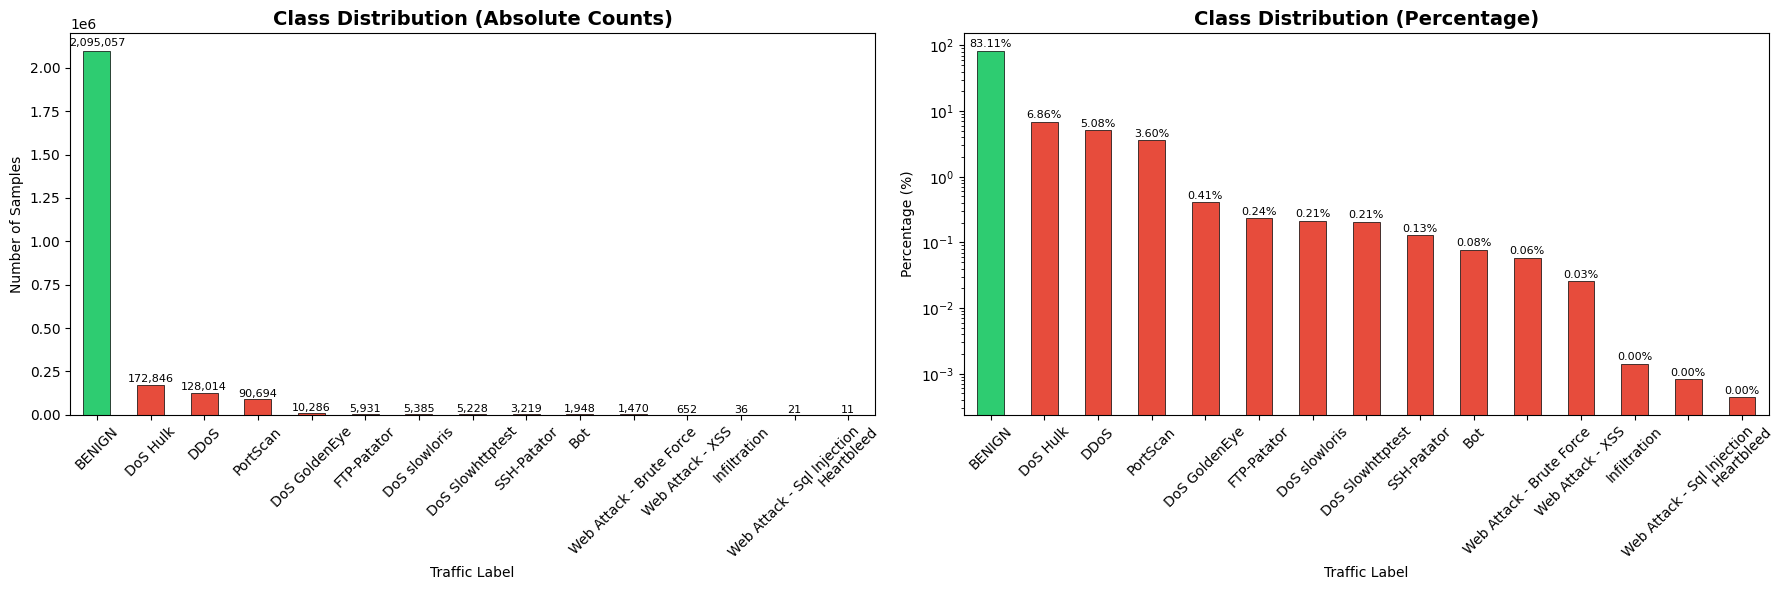

In [18]:
if eda_cfg.run_eda:
    # Class Distribution Bar Chart
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    label_counts = ml_df['Label'].value_counts()
    colors = ['#2ecc71' if label == 'BENIGN' else '#e74c3c' for label in label_counts.index]
    label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
    axes[0].set_title('Class Distribution (Absolute Counts)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Number of Samples')
    axes[0].set_xlabel('Traffic Label')
    axes[0].tick_params(axis='x', rotation=45)
    for i, (val, name) in enumerate(zip(label_counts.values, label_counts.index)):
        axes[0].text(i, val + val * 0.01, f'{val:,}', ha='center', va='bottom', fontsize=8)

    label_pct = (label_counts / label_counts.sum() * 100)
    label_pct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', linewidth=0.5)
    axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].set_xlabel('Traffic Label')
    axes[1].set_yscale('log')
    axes[1].tick_params(axis='x', rotation=45)
    for i, (val, name) in enumerate(zip(label_pct.values, label_pct.index)):
        axes[1].text(i, val + val * 0.05, f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("EDA visualizations DISABLED.")

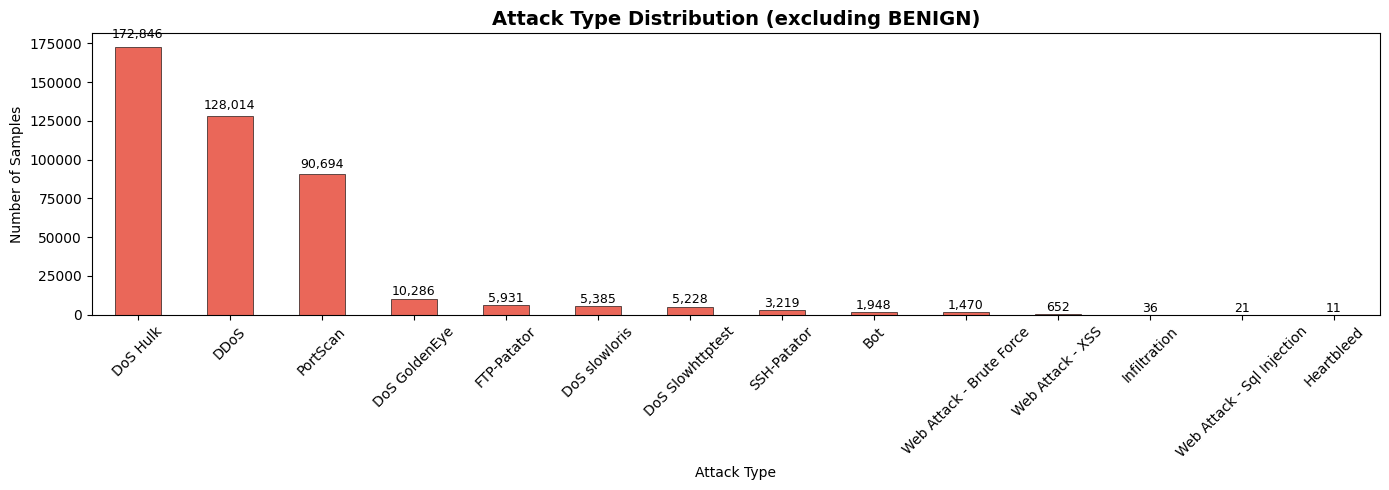

In [19]:
if eda_cfg.run_eda:
    # Attack types only
    attack_counts = label_counts[label_counts.index != 'BENIGN']

    fig, ax = plt.subplots(figsize=(14, 5))
    attack_counts.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.set_title('Attack Type Distribution (excluding BENIGN)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Samples')
    ax.set_xlabel('Attack Type')
    ax.tick_params(axis='x', rotation=45)
    for i, val in enumerate(attack_counts.values):
        ax.text(i, val + val * 0.02, f'{val:,}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

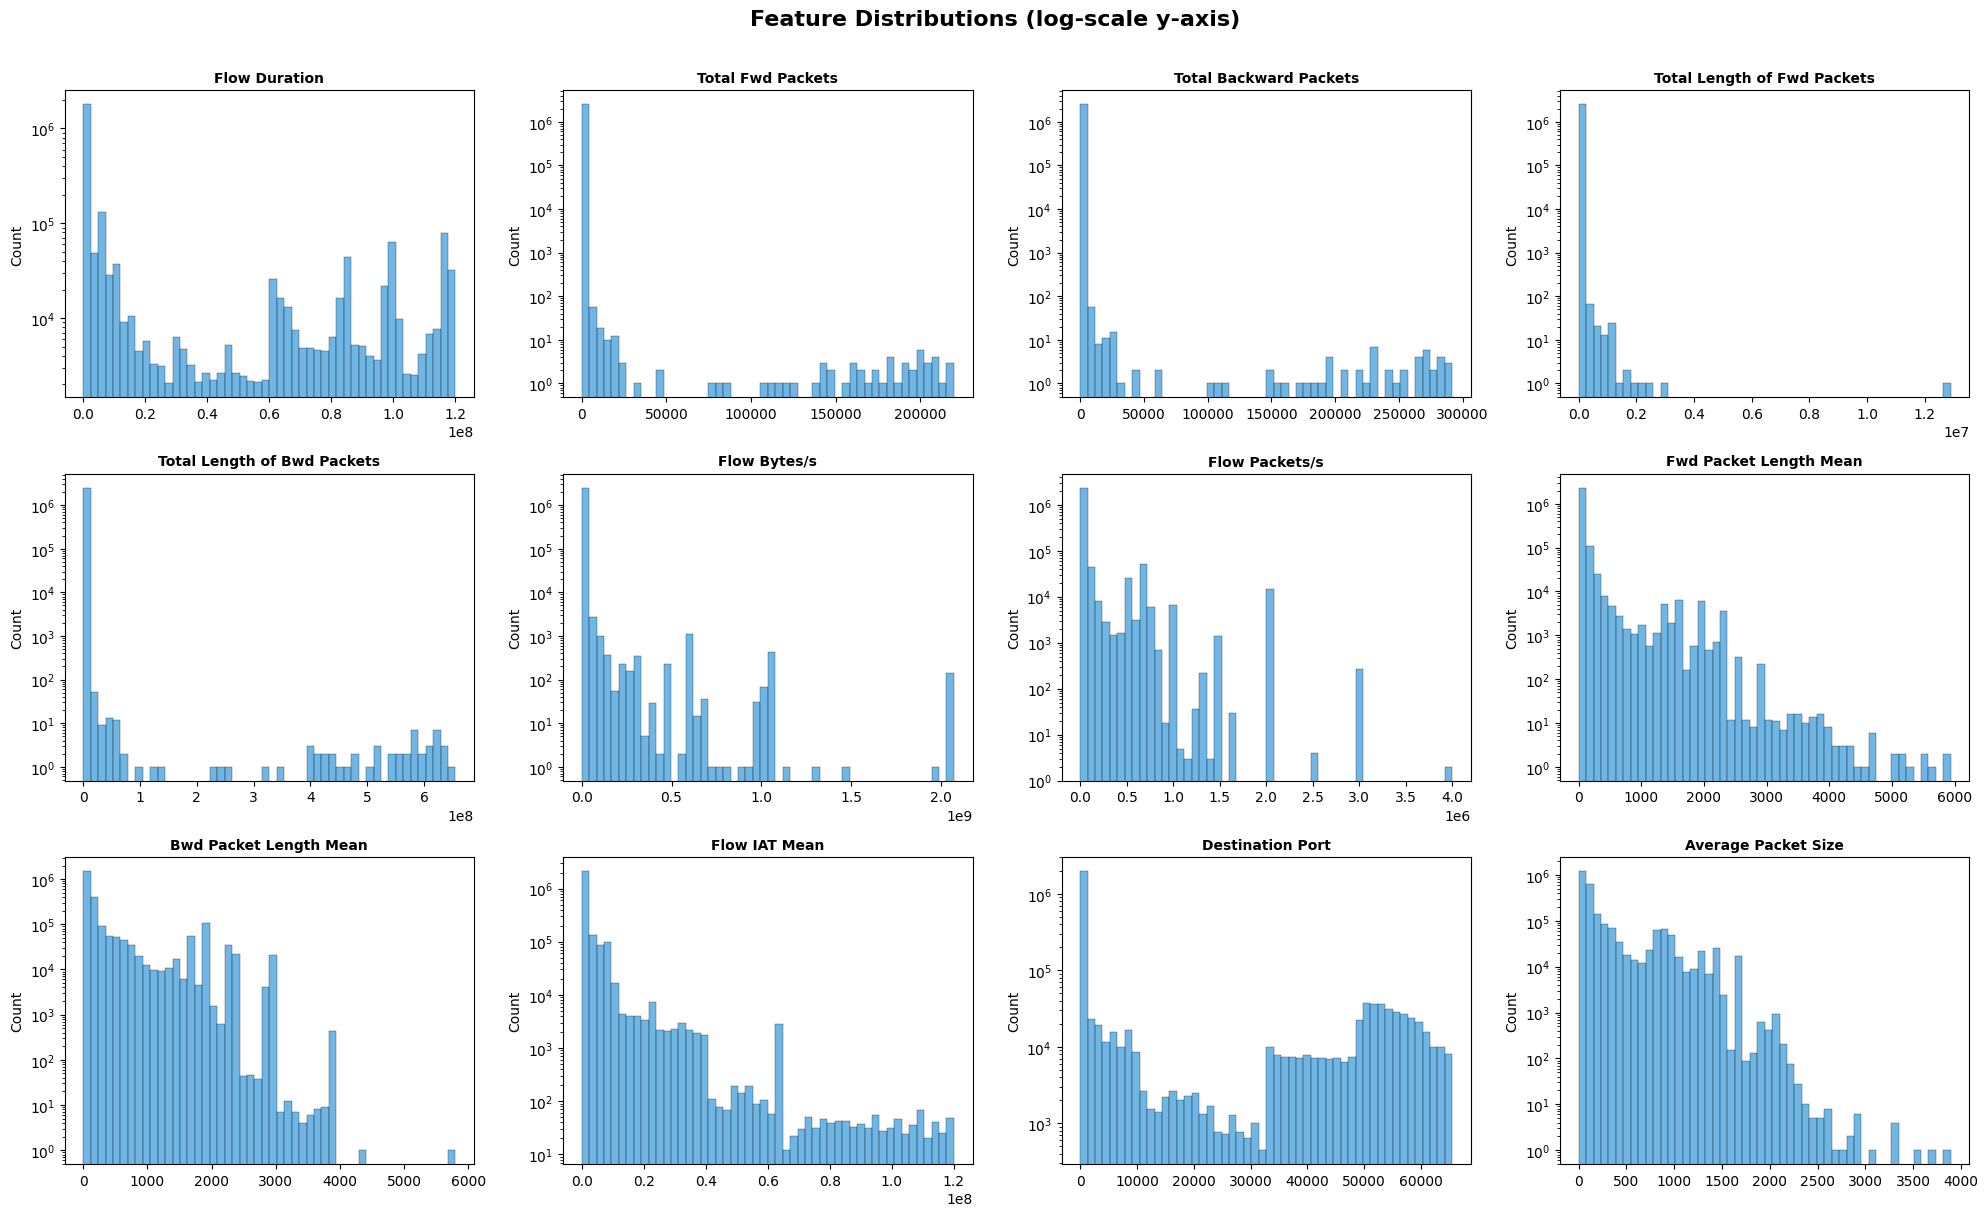

In [20]:
if eda_cfg.run_eda:
    # Feature Distributions - Histograms for key features
    key_features = eda_cfg.key_features

    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    axes = axes.flatten()

    for i, feat in enumerate(key_features):
        ax = axes[i]
        data = ml_df[feat].clip(lower=0)
        ax.hist(data, bins=50, color='#3498db', edgecolor='black', linewidth=0.3, alpha=0.7)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_ylabel('Count')
        ax.set_yscale('log')

    plt.suptitle('Feature Distributions (log-scale y-axis)', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

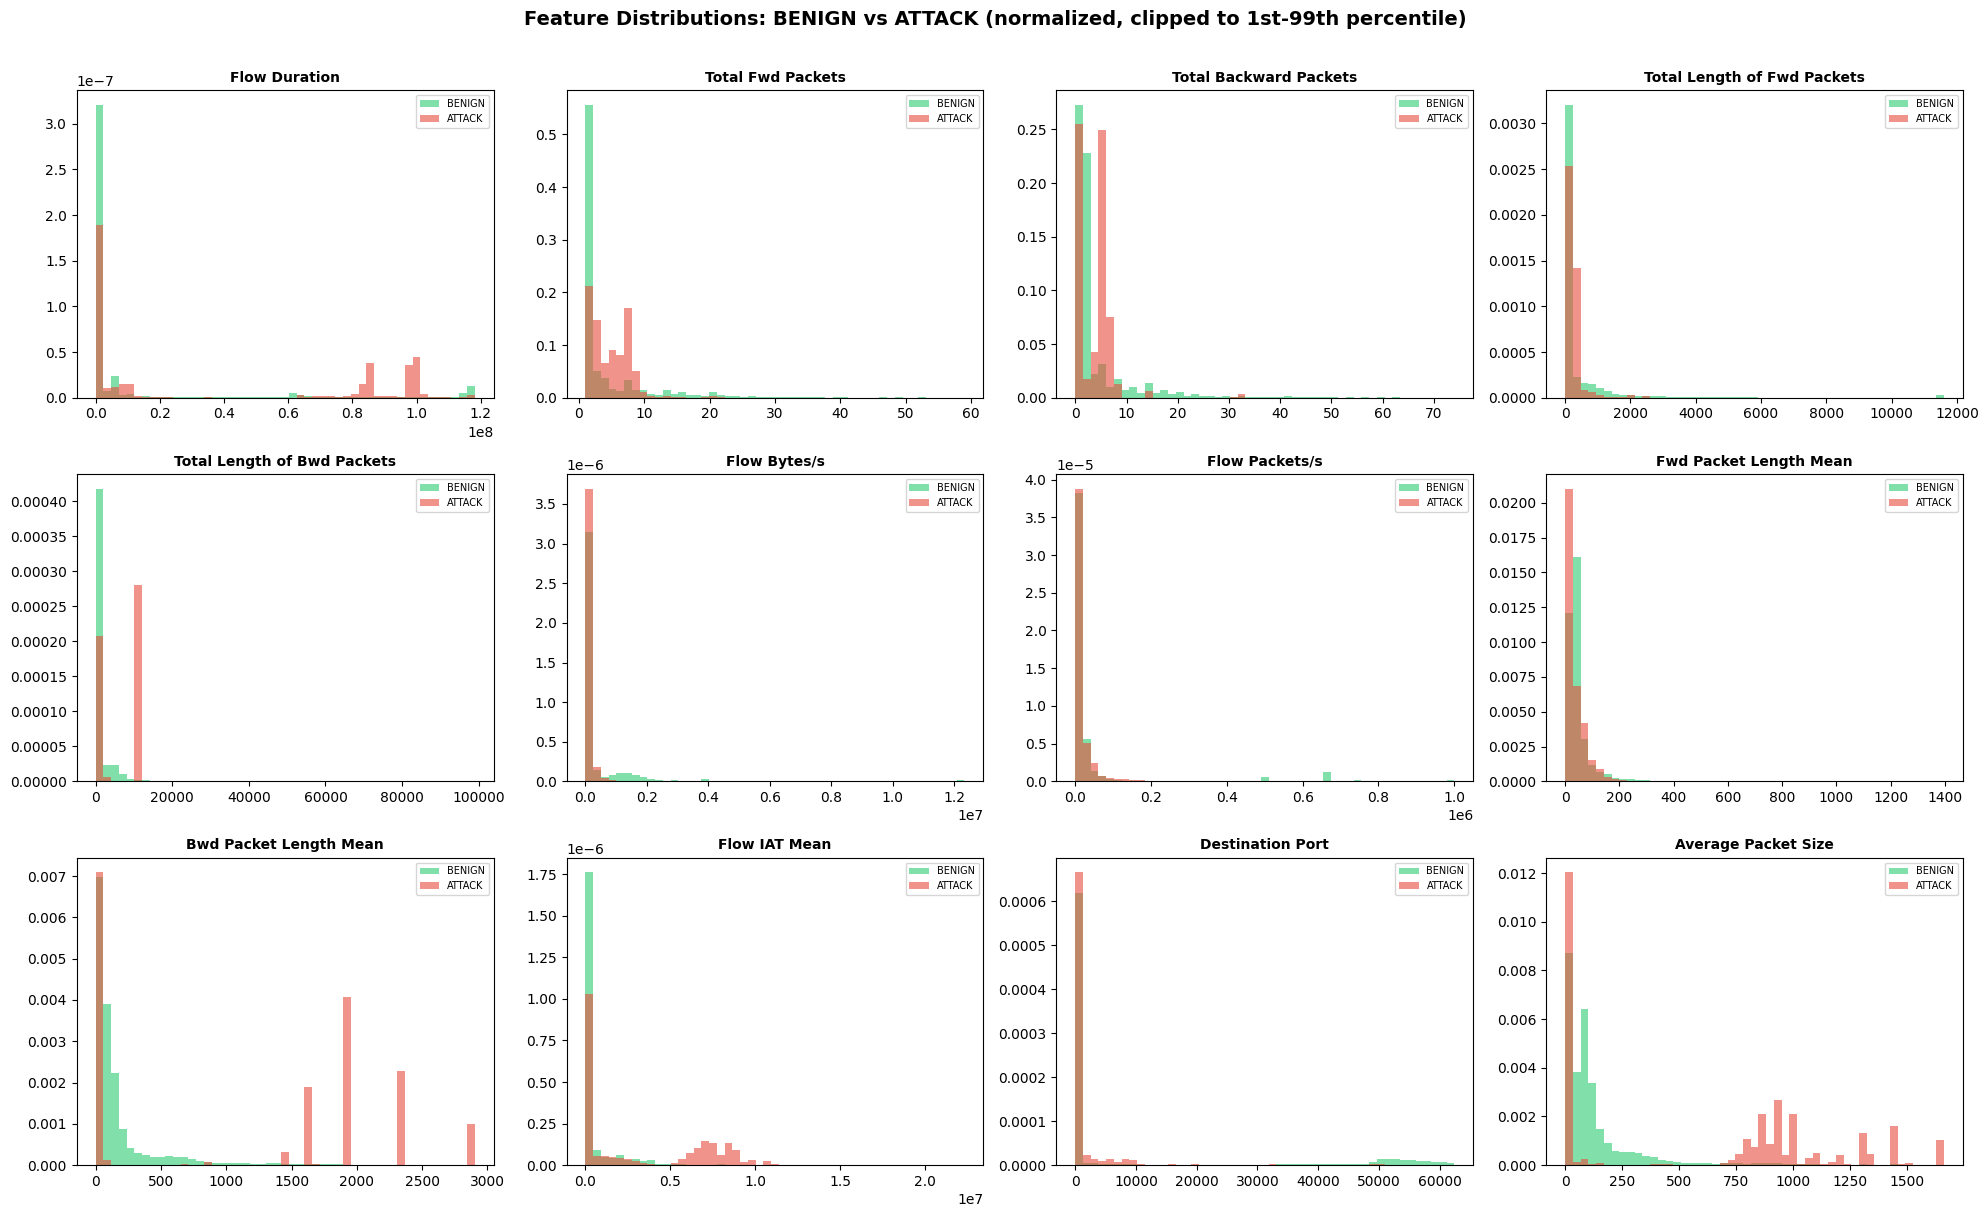

In [21]:
if eda_cfg.run_eda:
    # Feature distributions - Normal vs Attack comparison
    ml_df['is_attack'] = (ml_df['Label'] != 'BENIGN').astype(int)

    fig, axes = plt.subplots(3, 4, figsize=(20, 12))
    axes = axes.flatten()

    for i, feat in enumerate(key_features):
        ax = axes[i]
        benign_data = ml_df.loc[ml_df['is_attack'] == 0, feat]
        attack_data = ml_df.loc[ml_df['is_attack'] == 1, feat]

        low = min(benign_data.quantile(0.01), attack_data.quantile(0.01))
        high = max(benign_data.quantile(0.99), attack_data.quantile(0.99))
        bins = np.linspace(low, high, 50)

        ax.hist(benign_data, bins=bins, alpha=0.6, label='BENIGN', color='#2ecc71', density=True)
        ax.hist(attack_data, bins=bins, alpha=0.6, label='ATTACK', color='#e74c3c', density=True)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.legend(fontsize=7)

    for j in range(len(key_features), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Feature Distributions: BENIGN vs ATTACK (normalized, clipped to 1st-99th percentile)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

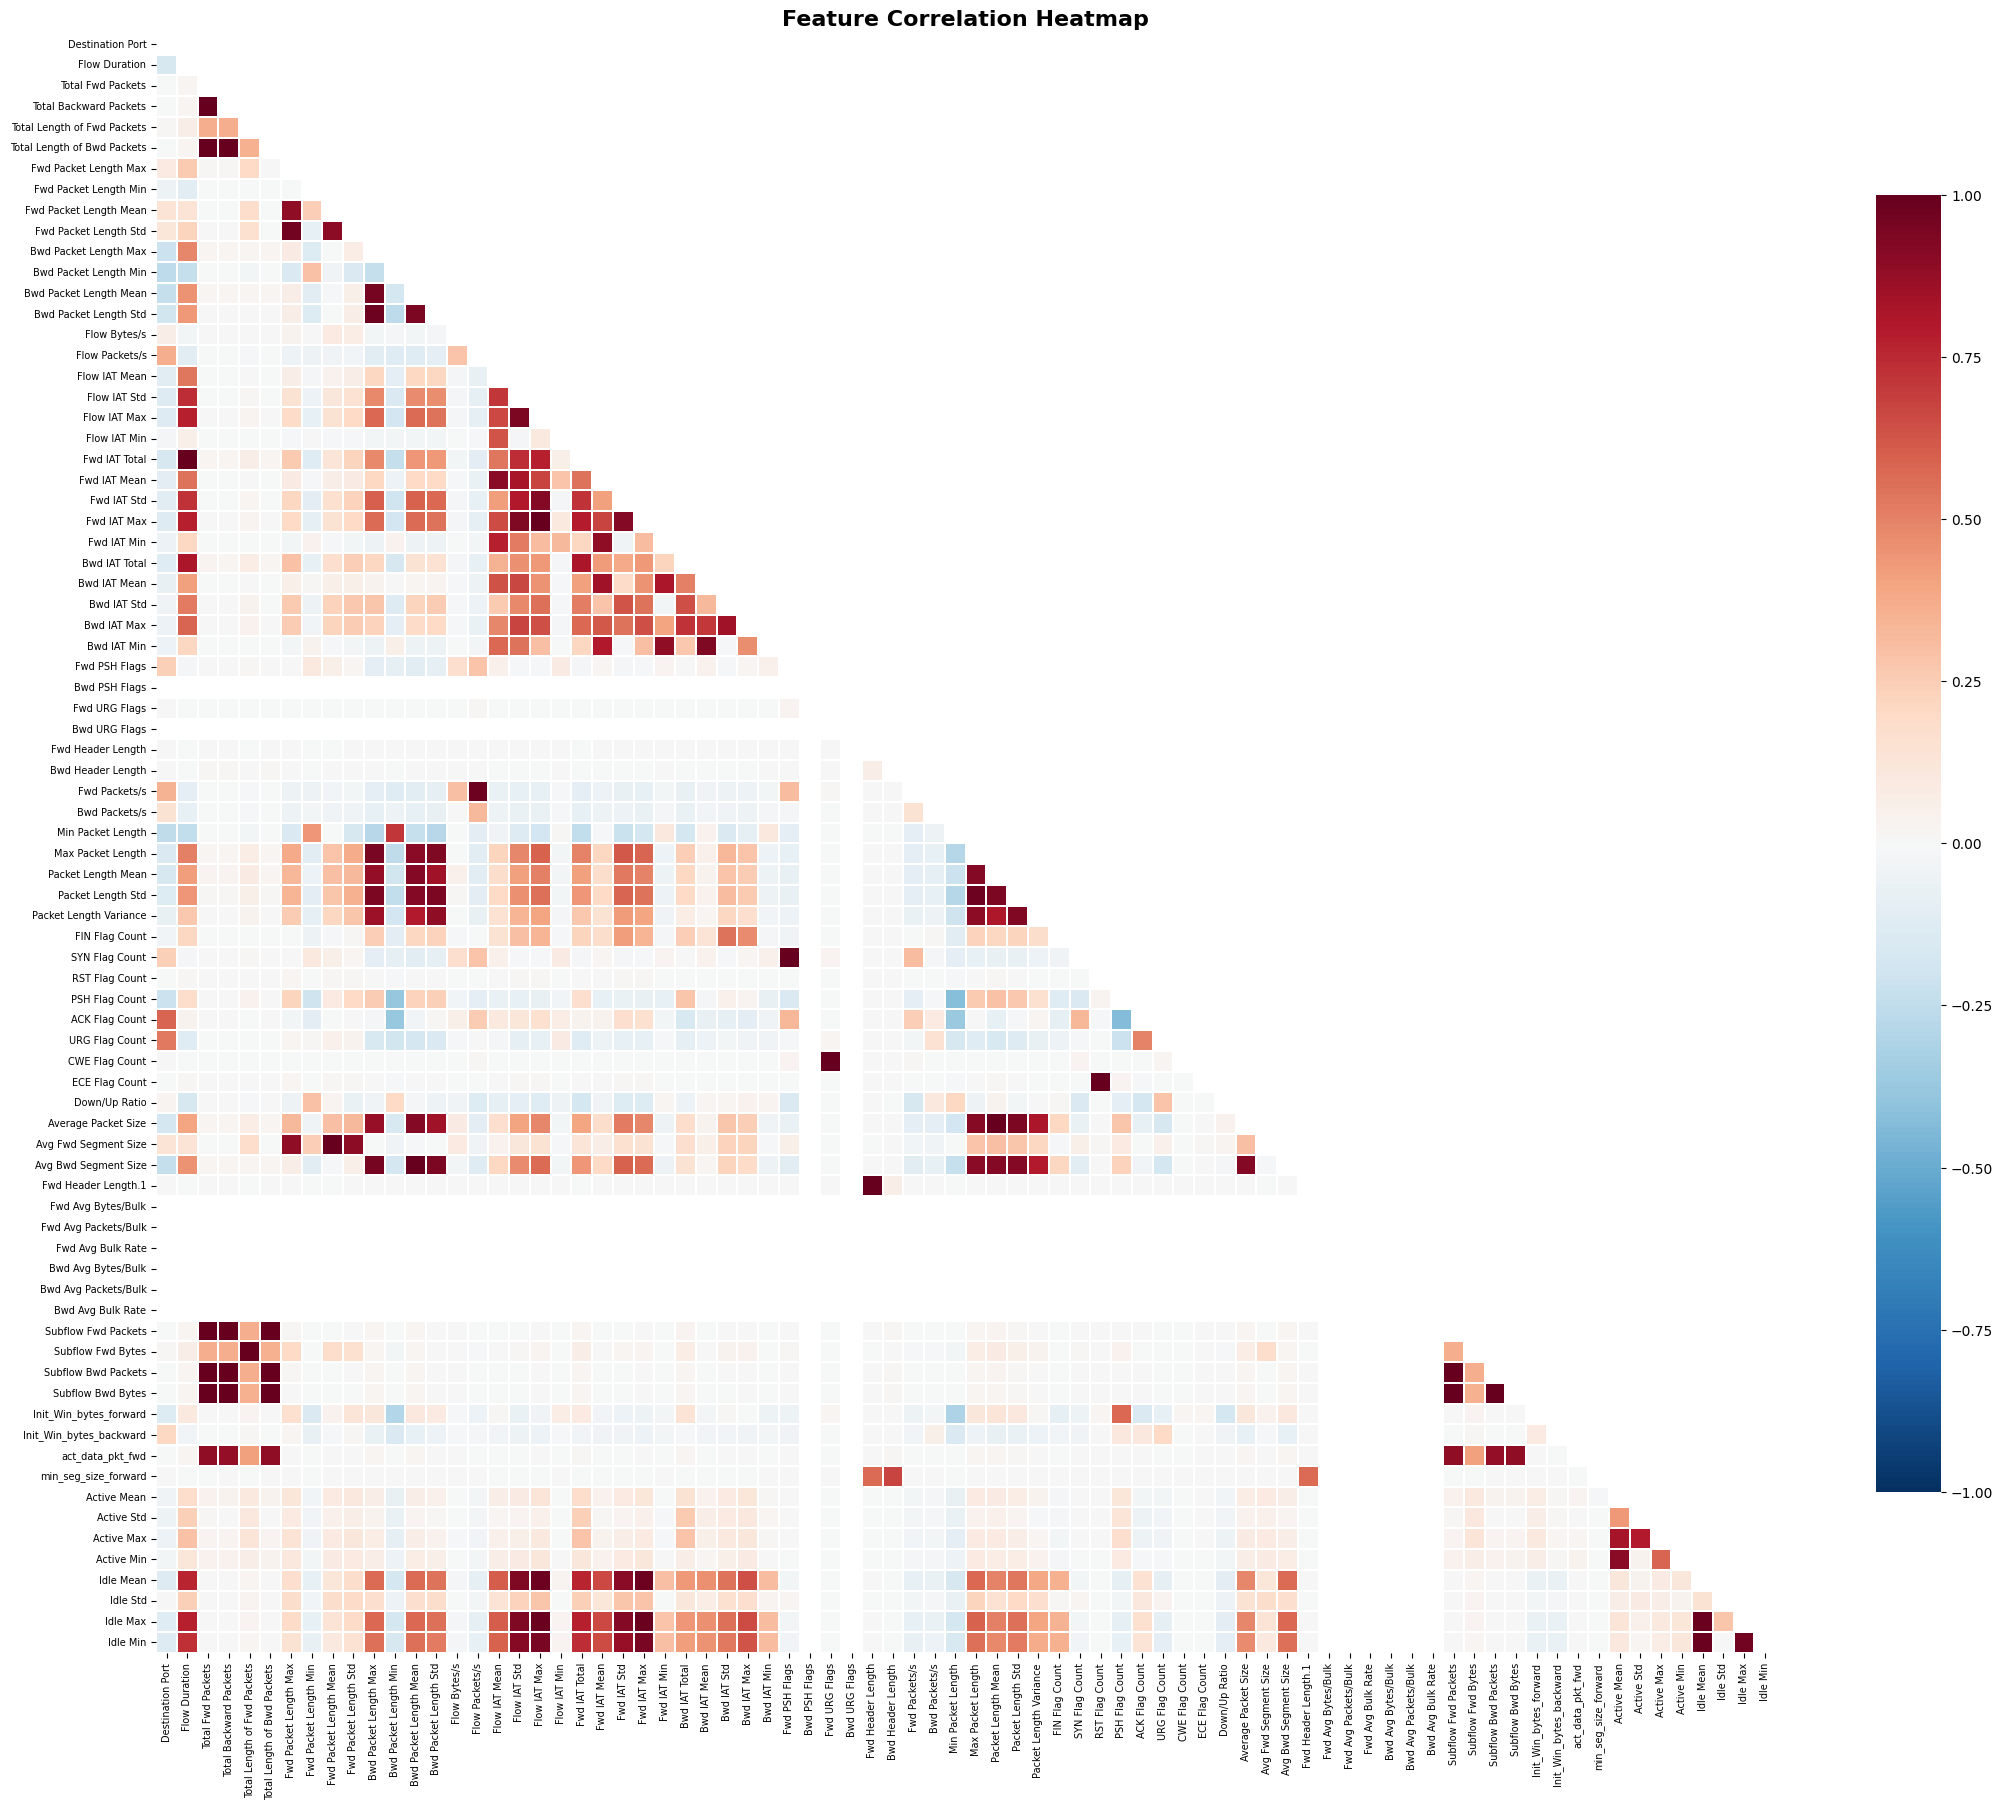

In [22]:
if eda_cfg.run_eda:
    # Correlation Heatmap
    ml_numeric_cols = ml_df.select_dtypes(include=[np.number]).columns.tolist()
    corr_cols = [c for c in ml_numeric_cols if c != 'is_attack']

    corr_matrix = ml_df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(22, 18))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
                square=True, linewidths=0.1, ax=ax,
                cbar_kws={"shrink": 0.8},
                xticklabels=True, yticklabels=True,
                vmin=-1, vmax=1)
    ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=7)
    plt.tight_layout()
    plt.show()

In [23]:
if eda_cfg.run_eda:
    # Highly correlated feature pairs
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.95:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))

    high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

    print(f"Highly Correlated Feature Pairs (|r| > 0.95)")
    print(f"\n{len(high_corr_pairs)} pairs:\n")
    for f1, f2, r in high_corr_pairs:
        print(f"{r:+.4f} {f1} - {f2}")

Highly Correlated Feature Pairs (|r| > 0.95)

39 pairs:

+1.0000 Bwd Packet Length Mean - Avg Bwd Segment Size
+1.0000 Total Fwd Packets - Subflow Fwd Packets
+1.0000 Total Backward Packets - Subflow Bwd Packets
+1.0000 Fwd Packet Length Mean - Avg Fwd Segment Size
+1.0000 Fwd PSH Flags - SYN Flag Count
+1.0000 Fwd URG Flags - CWE Flag Count
+1.0000 Fwd Header Length - Fwd Header Length.1
+1.0000 Total Length of Bwd Packets - Subflow Bwd Bytes
+1.0000 Total Length of Fwd Packets - Subflow Fwd Bytes
+0.9991 Total Fwd Packets - Total Backward Packets
+0.9991 Total Fwd Packets - Subflow Bwd Packets
+0.9991 Total Backward Packets - Subflow Fwd Packets
+0.9991 Subflow Fwd Packets - Subflow Bwd Packets
+0.9985 Flow Duration - Fwd IAT Total
+0.9981 Flow IAT Max - Fwd IAT Max
+0.9978 Packet Length Mean - Average Packet Size
+0.9978 RST Flag Count - ECE Flag Count
+0.9970 Total Fwd Packets - Total Length of Bwd Packets
+0.9970 Total Length of Bwd Packets - Subflow Fwd Packets
+0.9970 Total Fwd 

Mean Feature Values Per Label

                            Flow Duration  Total Fwd Packets  Total Backward Packets  Total Length of Fwd Packets  Total Length of Bwd Packets  Flow Bytes/s  Flow Packets/s  Fwd Packet Length Mean  Bwd Packet Length Mean  Flow IAT Mean  Destination Port  Average Packet Size
Label                                                                                                                                                                                                                                                                             
BENIGN                        12160238.43              11.38                   13.09                       683.92                     20444.06    1675795.09        53557.48                   70.06                  171.12      971953.79          10058.51               131.19
Bot                             354185.44               3.21                    3.37                      2669.84                        64.33  

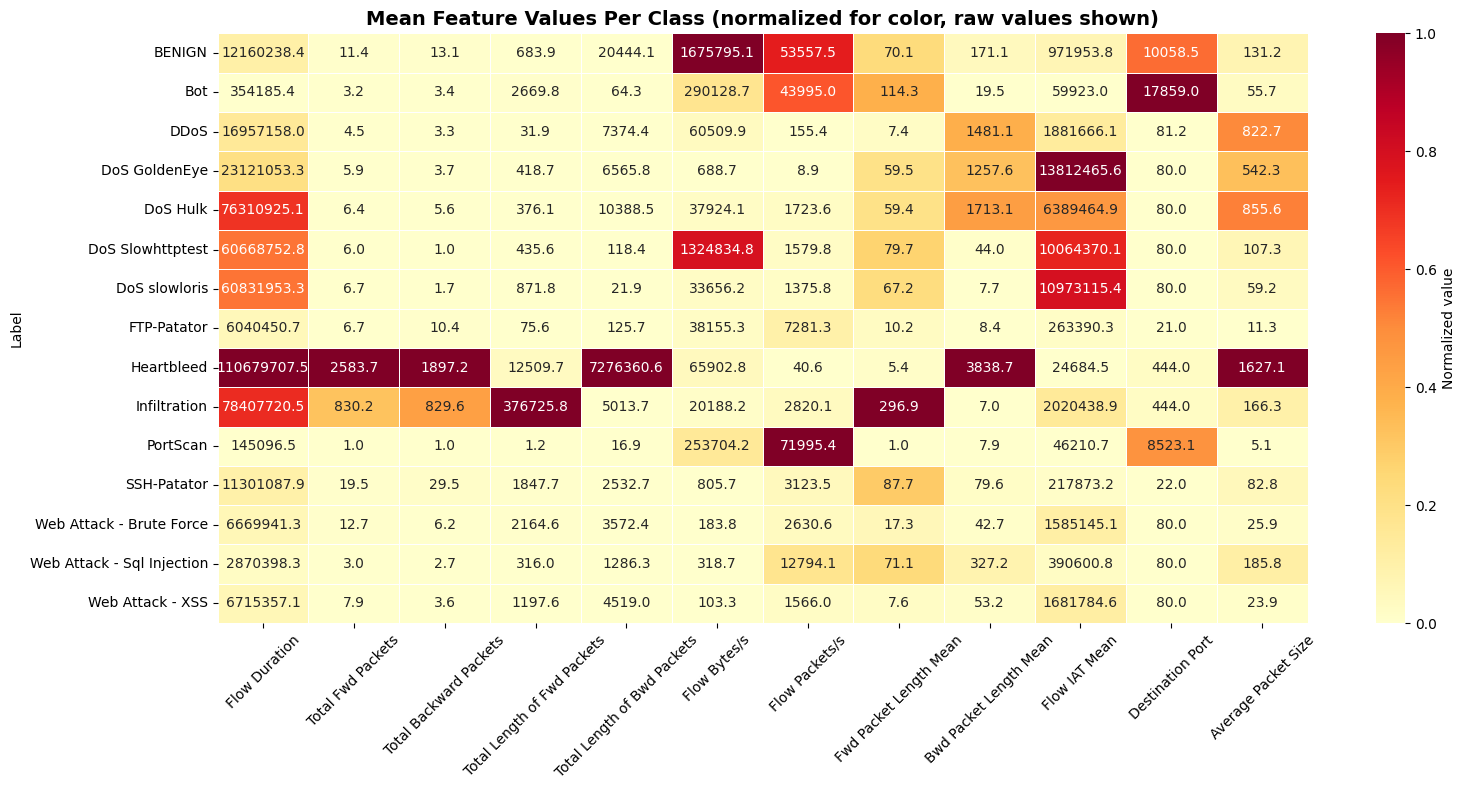

In [24]:
if eda_cfg.run_eda:
    # Summary statistics per class - mean of key features
    print("Mean Feature Values Per Label\n")
    class_means = ml_df.groupby('Label')[key_features].mean()
    print(class_means.round(2).to_string())

    fig, ax = plt.subplots(figsize=(16, 8))
    scaler_viz = MinMaxScaler()
    class_means_norm = pd.DataFrame(
        scaler_viz.fit_transform(class_means),
        index=class_means.index,
        columns=class_means.columns
    )
    sns.heatmap(class_means_norm, cmap='YlOrRd', annot=class_means.round(1).values, fmt='',
                ax=ax, linewidths=0.5, cbar_kws={"label": "Normalized value"})
    ax.set_title('Mean Feature Values Per Class (normalized for color, raw values shown)',
                 fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

## 6. Data Engineering

### 6.1 MachineLearningCVE (`ml_df`)

In [25]:
if prep_cfg.drop_constant_columns:
    constant_to_drop = [
        'Bwd PSH Flags', 'Bwd URG Flags',
        'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
        'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate',
    ]
    ml_before_cols = ml_df.shape[1]
    ml_df.drop(columns=[c for c in constant_to_drop if c in ml_df.columns], inplace=True)
    print(f"Dropped {ml_before_cols - ml_df.shape[1]} constant columns from ml")
# else:
#     print("Constant column removal DISABLED.")

Dropped 8 constant columns from ml


In [26]:
if prep_cfg.drop_redundant_columns:
    redundant_to_drop = [
        'Subflow Fwd Packets', 'Subflow Bwd Packets',
        'Subflow Fwd Bytes', 'Subflow Bwd Bytes',
        'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
        'Fwd Header Length.1',
    ]
    ml_before_cols = ml_df.shape[1]
    ml_df.drop(columns=[c for c in redundant_to_drop if c in ml_df.columns], inplace=True)
    print(f"Dropped {ml_before_cols - ml_df.shape[1]} redundant columns from ml")
# else:
#     print("Redundant column removal DISABLED.")

Dropped 7 redundant columns from ml


In [27]:
cols_to_remove = []
if 'is_attack' in ml_df.columns:
    cols_to_remove.append('is_attack')
if 'source_file' in ml_df.columns:
    cols_to_remove.append('source_file')

ml_df.drop(columns=[c for c in cols_to_remove if c in ml_df.columns], inplace=True)
print(f"Removed helper and metadata columns from ml")

Removed helper and metadata columns from ml


In [28]:
# Encode labels
le = LabelEncoder()
le.fit(ml_df['Label'])

ml_df['label_encoded'] = le.transform(ml_df['Label'])

label_mapping = dict(zip(le.classes_.tolist(), [int(x) for x in le.transform(le.classes_)]))
print("Label Encoding Mapping ml:\n")
for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"{code} - {label}")

Label Encoding Mapping ml:

0 - BENIGN
1 - Bot
2 - DDoS
3 - DoS GoldenEye
4 - DoS Hulk
5 - DoS Slowhttptest
6 - DoS slowloris
7 - FTP-Patator
8 - Heartbleed
9 - Infiltration
10 - PortScan
11 - SSH-Patator
12 - Web Attack - Brute Force
13 - Web Attack - Sql Injection
14 - Web Attack - XSS


### 6.2 TrafficLabelling (`tl_df`)

In [29]:
if prep_cfg.drop_constant_columns:
    constant_to_drop = [
        'Bwd PSH Flags', 'Bwd URG Flags',
        'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
        'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate',
    ]
    tl_before_cols = tl_df.shape[1]
    tl_df.drop(columns=[c for c in constant_to_drop if c in tl_df.columns], inplace=True)
    print(f"Dropped {tl_before_cols - tl_df.shape[1]} constant columns from tl")

Dropped 8 constant columns from tl


In [30]:
if prep_cfg.drop_redundant_columns:
    redundant_to_drop = [
        'Subflow Fwd Packets', 'Subflow Bwd Packets',
        'Subflow Fwd Bytes', 'Subflow Bwd Bytes',
        'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
        'Fwd Header Length.1',
    ]
    tl_before_cols = tl_df.shape[1]
    tl_df.drop(columns=[c for c in redundant_to_drop if c in tl_df.columns], inplace=True)
    print(f"Dropped {tl_before_cols - tl_df.shape[1]} redundant columns from tl")

Dropped 7 redundant columns from tl


In [31]:
cols_to_remove = []
if 'is_attack' in tl_df.columns:
    cols_to_remove.append('is_attack')
if 'source_file' in tl_df.columns:
    cols_to_remove.append('source_file')

tl_df.drop(columns=[c for c in cols_to_remove if c in tl_df.columns], inplace=True)
print(f"Removed helper and metadata columns from tl")

Removed helper and metadata columns from tl


In [32]:
# Encode labels
tl_df['label_encoded'] = le.transform(tl_df['Label'])

print("Label Encoding Mapping tl:")
for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"{code} - {label}")

Label Encoding Mapping tl:
0 - BENIGN
1 - Bot
2 - DDoS
3 - DoS GoldenEye
4 - DoS Hulk
5 - DoS Slowhttptest
6 - DoS slowloris
7 - FTP-Patator
8 - Heartbleed
9 - Infiltration
10 - PortScan
11 - SSH-Patator
12 - Web Attack - Brute Force
13 - Web Attack - Sql Injection
14 - Web Attack - XSS


## 7. Correlation-Based Feature Selection (Optional)

In [33]:
# Determine feature columns
non_feature_cols_ml = ['Label', 'label_encoded']
feature_cols = [c for c in ml_df.columns if c not in non_feature_cols_ml]

# print(f"Total feature columns: {len(feature_cols)}")

selected_feature_cols = None

if corr_cfg.enabled:
    # print(f"\nCorrelation-based feature selection ENABLED")
    print(f"Method: {corr_cfg.method}, Threshold: {corr_cfg.correlation_threshold}")

    # Compute correlation of each feature with the encoded target
    corr_with_target = ml_df[feature_cols + ['label_encoded']].corr(method=corr_cfg.method)['label_encoded'].drop('label_encoded')
    corr_with_target_abs = corr_with_target.abs().sort_values(ascending=False)

    # print(f"\nFeature correlations with target (top 20):")
    # for feat, corr_val in corr_with_target_abs.head(20).items():
    #     direction = '+' if corr_with_target[feat] > 0 else '-'
    #     print(f"  {direction}{corr_val:.4f}  {feat}")

    selected_feature_cols = corr_with_target_abs[corr_with_target_abs >= corr_cfg.correlation_threshold].index.tolist()

    print(f"\nSelected {len(selected_feature_cols)} features (|corr| >= {corr_cfg.correlation_threshold}):")
    for feat in selected_feature_cols:
        print(f"{feat} {corr_with_target[feat]:+.4f}")

    # dropped = [f for f in feature_cols if f not in selected_feature_cols]
    # print(f"\nDropped {len(dropped)} features below threshold.")
# else:
#     print("Correlation-based feature selection DISABLED. Using all features.")

Method: spearman, Threshold: 0.3

Selected 7 features (|corr| >= 0.3):
Bwd Packet Length Std +0.3553
Fwd IAT Std +0.3353
Idle Max +0.3216
Idle Mean +0.3206
Min Packet Length -0.3191
Idle Min +0.3173
Fwd Packet Length Min -0.3151


## 8. Save Prepared Data

In [34]:
if prep_cfg.save_prepared_csvs:
    os.makedirs(paths_cfg.output_dir, exist_ok=True)

    ml_path = os.path.join(paths_cfg.output_dir, 'ml_prepared.csv')
    ml_df.to_csv(ml_path, index=False)
    print(f"Saved MachineLearningCVE: {ml_path}")

    tl_path = os.path.join(paths_cfg.output_dir, 'tl_prepared.csv')
    tl_df.to_csv(tl_path, index=False)
    print(f"Saved TrafficLabelling: {tl_path}")

    metadata = {
        'feature_cols': feature_cols,
        'label_mapping': label_mapping,
        'ml_shape': list(ml_df.shape),
        'tl_shape': list(tl_df.shape),
    }
    if selected_feature_cols is not None:
        metadata['selected_feature_cols'] = selected_feature_cols
        metadata['correlation_threshold'] = corr_cfg.correlation_threshold
        metadata['correlation_method'] = corr_cfg.method

    meta_path = os.path.join(paths_cfg.output_dir, 'metadata.json')
    with open(meta_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"Saved metadata: {meta_path}")

# else:
#     print("CSV saving DISABLED. Data is only available in memory.")

Saved MachineLearningCVE: prepared_data/ml_prepared.csv
Saved TrafficLabelling: prepared_data/tl_prepared.csv
Saved metadata: prepared_data/metadata.json
